# Transformer-Based Model for Mental Health Text Classification

In this notebook, we implement **Approach 3** of our MindScope-AI project:  
a **Transformer-based classifier** using the pretrained model  
`mental/mental-bert-base-uncased` (MentalBERT).

**Key ideas:**
- Use **raw mental-health text** from `data/raw/sentiment_mental_health.csv`  
  (minimal text preprocessing, no lowercasing / punctuation removal).
- Fine-tune **MentalBERT** for **7-way mental-health classification**
  (Normal, Depression, Suicidal, Anxiety, Bipolar, Stress, Personality disorder).
- Keep the training flow consistent with the SVM and LSTM approaches:
  track train/validation loss, macro F1, and evaluate on the same test split.

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# SECTION 2: Load dataset

import pandas as pd

RAW_DATA_PATH = "/kaggle/input/raw-dataset/sentiment_mental_health.csv"

TEXT_COL = "statement"
LABEL_COL = "status"

df_raw = pd.read_csv(RAW_DATA_PATH)

print("Raw dataset loaded.")
print(f"Total rows (before cleaning): {len(df_raw)}")
print("Columns:", df_raw.columns.tolist())

Raw dataset loaded.
Total rows (before cleaning): 52681
Columns: ['Unnamed: 0', 'statement', 'status']


In [3]:
df_raw[[TEXT_COL, LABEL_COL]].head(5)

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
# Minimal cleaning: drop NaNs / empty text, strip spaces

before_rows = len(df_raw)

# Drop rows where text is NaN
df = df_raw.dropna(subset=[TEXT_COL]).copy()

# Strip spaces and drop rows that become empty
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL] != ""]

after_rows = len(df)

print(f"Rows dropped:         {before_rows - after_rows}")

# Basic label stats
unique_labels = df[LABEL_COL].unique().tolist()
print("\nUnique labels:", unique_labels)
print("\nLabel distribution (counts):")
print(df[LABEL_COL].value_counts())

Rows dropped:         0

Unique labels: ['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar', 'Personality disorder']

Label distribution (counts):
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


In [5]:
LABEL_ORDER = [
    "Anxiety",              
    "Bipolar",             
    "Depression",          
    "Normal",              
    "Personality disorder", 
    "Stress",              
    "Suicidal",           
]

In [6]:
# SECTION 3 – Cell 1: clean columns + label encoding (before split)

import numpy as np
import pandas as pd

# Drop Unnamed columns 
unnamed_cols = [col for col in df.columns if col.startswith("Unnamed")]

df = df.drop(columns=unnamed_cols)

label2id = {label: idx for idx, label in enumerate(LABEL_ORDER)}
id2label = {idx: label for label, idx in label2id.items()}

print("\nLabel mapping (status -> id):")
for label in LABEL_ORDER:
    print(f"{label:<20} -> {label2id[label]}")

# Add encoded label_id column to the full dataframe
df["label_id"] = df[LABEL_COL].map(label2id)

print("\nSample after cleaning & encoding:")
df.head()


Label mapping (status -> id):
Anxiety              -> 0
Bipolar              -> 1
Depression           -> 2
Normal               -> 3
Personality disorder -> 4
Stress               -> 5
Suicidal             -> 6

Sample after cleaning & encoding:


,statement,status,label_id
0,oh my gosh,Anxiety,0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,0
3,I've shifted my focus to something else but I'...,Anxiety,0
4,"I'm restless and restless, it's been a month n...",Anxiety,0


In [7]:
# SECTION 3 – Cell 2: Train/Val/Test split

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df[LABEL_COL],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[LABEL_COL],
    random_state=42,
)

print("\nSplit sizes:")
print(f"Dataset: {len(df_raw)}")
print(f"Train:   {len(train_df)}")
print(f"Val:     {len(val_df)}")
print(f"Test:    {len(test_df)}")

print("\nPreview of train split:")
train_df[[TEXT_COL, LABEL_COL, "label_id"]].head()



Split sizes:
Dataset: 52681
Train:   36876
Val:     7902
Test:    7903

Preview of train split:


,statement,status,label_id
20829,To put some context I have been though some th...,Suicidal,6
36377,@michaelgrainger @Scyranth *gigglessssssss* Ya...,Normal,3
20762,So right now they are planning to meet at the ...,Suicidal,6
30953,being broke is no fun.,Normal,3
30868,you don't need to worry about that.,Normal,3


In [8]:
# SECTION 3 – Cell 3: label distribution tables

DISPLAY_ORDER = [
    "Normal",
    "Depression",
    "Suicidal",
    "Anxiety",
    "Bipolar",
    "Stress",
    "Personality disorder",
]

def label_stats(split_df, split_name):
    counts = split_df[LABEL_COL].value_counts().reindex(DISPLAY_ORDER, fill_value=0)
    props  = split_df[LABEL_COL].value_counts(normalize=True).reindex(DISPLAY_ORDER, fill_value=0.0)

    stats_df = (
        pd.DataFrame({"count": counts, "proportion": props.round(3)})
        .rename_axis("status")
        .reset_index()
    )

    print(f"\n=== {split_name} label stats ===")
    display(stats_df)
    return stats_df

overall_stats = label_stats(df,       "Overall")
train_stats   = label_stats(train_df, "Train")
val_stats     = label_stats(val_df,   "Validation")
test_stats    = label_stats(test_df,  "Test")


=== Overall label stats ===


,status,count,proportion
0,Normal,16343,0.310
1,Depression,15404,0.292
2,Suicidal,10652,0.202
3,Anxiety,3841,0.073
4,Bipolar,2777,0.053
5,Stress,2587,0.049
6,Personality disorder,1077,0.020



=== Train label stats ===


,status,count,proportion
0,Normal,11440,0.310
1,Depression,10782,0.292
2,Suicidal,7456,0.202
3,Anxiety,2689,0.073
4,Bipolar,1944,0.053
5,Stress,1811,0.049
6,Personality disorder,754,0.020



=== Validation label stats ===


,status,count,proportion
0,Normal,2451,0.310
1,Depression,2311,0.292
2,Suicidal,1598,0.202
3,Anxiety,576,0.073
4,Bipolar,416,0.053
5,Stress,388,0.049
6,Personality disorder,162,0.021



=== Test label stats ===


,status,count,proportion
0,Normal,2452,0.310
1,Depression,2311,0.292
2,Suicidal,1598,0.202
3,Anxiety,576,0.073
4,Bipolar,417,0.053
5,Stress,388,0.049
6,Personality disorder,161,0.020


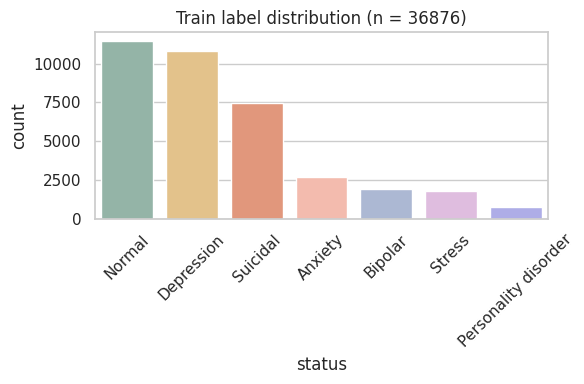

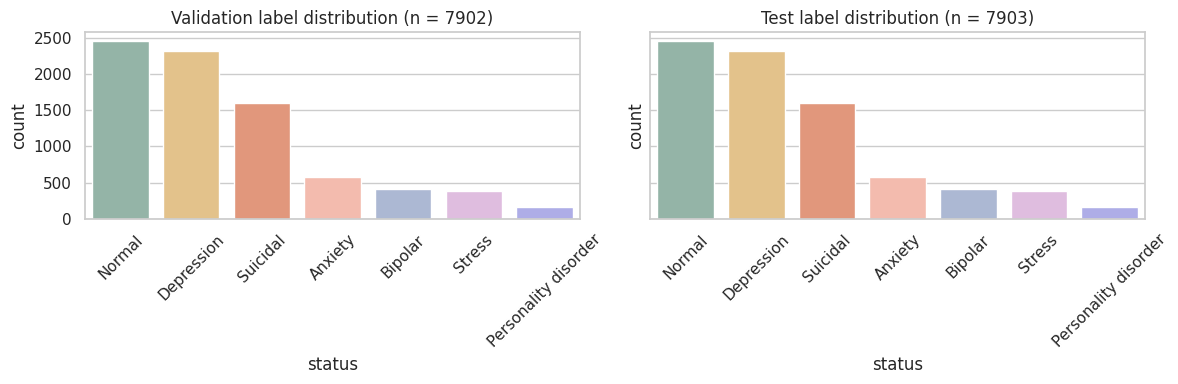

In [9]:
# SECTION 3 – Cell 4: visualise label counts with better y-scales

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

status_colors = {
    "Normal":               "#8FB9A8", 
    "Depression":           "#F2C57C",  
    "Suicidal":             "#F28F6B", 
    "Anxiety":              "#FFB4A2",  
    "Bipolar":              "#A5B5D9", 
    "Stress":               "#E4B7E5",  
    "Personality disorder": "#A4A3F1",
}

palette = [status_colors[label] for label in DISPLAY_ORDER]

# --- 1) Train split ---
plt.figure(figsize=(6,4))
sns.countplot(
    data=train_df,
    x=LABEL_COL,
    order=DISPLAY_ORDER,
    palette=palette,
)
plt.title(f"Train label distribution (n = {len(train_df)})")
plt.xlabel("status")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 2) Val & Test split ---
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

splits_small = [
    ("Validation label distribution", val_df),
    ("Test label distribution",       test_df),
]

for ax, (title, split_df) in zip(axes, splits_small):
    sns.countplot(
        data=split_df,
        x=LABEL_COL,
        order=DISPLAY_ORDER,
        palette=palette,
        ax=ax,
    )
    ax.set_title(f"{title} (n = {len(split_df)})")
    ax.set_xlabel("status")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [10]:
# SECTION 4 – Cell 2: load tokenizer (MentalBERT via Kaggle secrets)

from kaggle_secrets import UserSecretsClient
from transformers import AutoTokenizer

# Get HF token from Kaggle secrets
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")  

print("HF token found:", "YES" if hf_token else "NO")

PREFERRED_MODEL = "mental/mental-bert-base-uncased"

MODEL_NAME = None

print(f"\nTrying to load tokenizer from: {PREFERRED_MODEL}")
tokenizer = AutoTokenizer.from_pretrained(
    PREFERRED_MODEL,
    use_auth_token=hf_token
)
MODEL_NAME = PREFERRED_MODEL

print("\nLoaded tokenizer from:", MODEL_NAME)
print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Tokenizer padding side:", tokenizer.padding_side)
print("Tokenizer model max length:", tokenizer.model_max_length)


HF token found: YES

Trying to load tokenizer from: mental/mental-bert-base-uncased


/usr/local/lib/python3.11/dist-packages/transformers/models/auto/tokenization_auto.py:935: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(



Loaded tokenizer from: mental/mental-bert-base-uncased
Tokenizer vocab size: 30522
Tokenizer padding side: right
Tokenizer model max length: 512


In [11]:
# SECTION 4 – Cell 3: analyse token length distribution

import numpy as np
import matplotlib.pyplot as plt

# Encode train statements without truncation/padding to inspect true lengths
train_texts = train_df["statement"].tolist()

encodings = tokenizer(
    train_texts,
    padding=False,
    truncation=False,
)

seq_lengths = np.array([len(ids) for ids in encodings["input_ids"]])

print("Number of train samples:", len(seq_lengths))
print("\nToken length stats (train):")
print("Min:   ", int(seq_lengths.min()))
print("Max:   ", int(seq_lengths.max()))
print("Mean:  ", float(seq_lengths.mean()))
print("Median:", int(np.percentile(seq_lengths, 50)))

Token indices sequence length is longer than the specified maximum sequence length for this model (604 > 512). Running this sequence through the model will result in indexing errors


Number of train samples: 36876

Token length stats (train):
Min:    3
Max:    7562
Mean:   135.67100553205336
Median: 77


In [12]:
# SECTION 4 – Cell 4: encode all splits with padding & truncation

# Based on length stats (median ~77, mean ~136, long tail up to 7.5k)
# 256 keeps most information while controlling memory.
MAX_LEN = 256

def encode_split(split_df):
    enc = tokenizer(
        split_df[TEXT_COL].tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]
    labels = torch.tensor(split_df["label_id"].values, dtype=torch.long)
    return input_ids, attention_mask, labels

train_input_ids, train_attention_mask, train_labels = encode_split(train_df)
val_input_ids,   val_attention_mask,   val_labels   = encode_split(val_df)
test_input_ids,  test_attention_mask,  test_labels  = encode_split(test_df)

print("Max length used:", MAX_LEN)
print("\nTensor shapes:")
print("Train input_ids      :", train_input_ids.shape)
print("Train attention_mask :", train_attention_mask.shape)
print("Train labels         :", train_labels.shape)

print("\nVal input_ids        :", val_input_ids.shape)
print("Val attention_mask   :", val_attention_mask.shape)
print("Val labels           :", val_labels.shape)

print("\nTest input_ids       :", test_input_ids.shape)
print("Test attention_mask  :", test_attention_mask.shape)
print("Test labels          :", test_labels.shape)

# Quick sanity check example
idx = 0
print("\nExample encoded text (train[idx]):")
print("Original text:\n", train_df[TEXT_COL].iloc[idx])
print("Token IDs (first 40):\n", train_input_ids[idx][:40].tolist(), "...")
print("Decoded back:", tokenizer.decode(train_input_ids[idx], skip_special_tokens=True))


Max length used: 256

Tensor shapes:
Train input_ids      : torch.Size([36876, 256])
Train attention_mask : torch.Size([36876, 256])
Train labels         : torch.Size([36876])

Val input_ids        : torch.Size([7902, 256])
Val attention_mask   : torch.Size([7902, 256])
Val labels           : torch.Size([7902])

Test input_ids       : torch.Size([7903, 256])
Test attention_mask  : torch.Size([7903, 256])
Test labels          : torch.Size([7903])

Example encoded text (train[idx]):
Original text:
 To put some context I have been though some things in my life that I will probably explain in another post, just a little summary, when I was kid I was nearly raped by my cousin, I never told to my family, I grew up with some anxiety, my parents were a bit strict with me like physically harm me and saying things like I am stupid and that kind of things when I was a child, (I now understand why and that is because my mother also had some mental issues that now she cured and we have a good relat

In [13]:
# SECTION 5 – Cell 2: PyTorch Dataset class for MentalBERT

from torch.utils.data import Dataset

class MentalHealthBERTDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }

In [14]:
# SECTION 5 – Cell 3: create train/val/test dataset objects

train_dataset = MentalHealthBERTDataset(train_input_ids, train_attention_mask, train_labels)

val_dataset = MentalHealthBERTDataset(val_input_ids, val_attention_mask, val_labels)

test_dataset = MentalHealthBERTDataset(test_input_ids, test_attention_mask, test_labels)

print("Dataset objects created.")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")
print(f"Test dataset size:  {len(test_dataset)}")


Dataset objects created.
Train dataset size: 36876
Val dataset size:   7902
Test dataset size:  7903


In [15]:
# SECTION 5 – Cell 4: Create DataLoaders

from torch.utils.data import DataLoader

BATCH_SIZE = 16  # good balance for BERT fine-tuning

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("DataLoaders created successfully.")
print("\nSummary:")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train steps per epoch: {len(train_loader)}")
print(f"Val steps per epoch:   {len(val_loader)}")
print(f"Test steps per epoch:  {len(test_loader)}")


DataLoaders created successfully.

Summary:
Batch size: 16
Train steps per epoch: 2305
Val steps per epoch:   494
Test steps per epoch:  494


In [16]:
# SECTION 5 – Cell 5: inspect one training batch

batch = next(iter(train_loader))

print("Batch tensors:")
print("input_ids      :", batch["input_ids"].shape)
print("attention_mask :", batch["attention_mask"].shape)
print("labels         :", batch["labels"].shape)

print("\nFirst sample label_id:", batch["labels"][0].item())
print("Decoded text:")
print(tokenizer.decode(batch["input_ids"][0], skip_special_tokens=True))

Batch tensors:
input_ids      : torch.Size([16, 256])
attention_mask : torch.Size([16, 256])
labels         : torch.Size([16])

First sample label_id: 3
Decoded text:
but we need new taxes to pay for highways, schools, and prisons.


In [17]:
# Fix protobuf issue that causes "MessageFactory has no attribute GetPrototype" noise
!pip install -q protobuf==3.20.*

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [18]:
# SECTION 6 – Cell 2: Load MentalBERT classification model

from kaggle_secrets import UserSecretsClient
from transformers import AutoModelForSequenceClassification
import torch
import torch.nn as nn

# Get HF token from Kaggle secrets
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

print("HF token found:", "YES" if hf_token else "NO")

PREFERRED_MODEL = "mental/mental-bert-base-uncased"
MODEL_NAME = PREFERRED_MODEL

NUM_LABELS = len(LABEL_ORDER)

print(f"\nLoading model from: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    token=hf_token,        
)

model.to(device)

# Parameter stats
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nModel loaded successfully.")
print("MODEL_NAME:", MODEL_NAME)
print(f"Number of labels: {NUM_LABELS}")
print("Model is on device:", next(model.parameters()).device)

HF token found: YES

Loading model from: mental/mental-bert-base-uncased


2025-11-23 06:02:19.787243: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763877739.808649     161 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763877739.815177     161 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model loaded successfully.
MODEL_NAME: mental/mental-bert-base-uncased
Number of labels: 7
Model is on device: cuda:0


In [19]:
# SECTION 6 – Cell 3: compute class weights for imbalanced labels

from sklearn.utils.class_weight import compute_class_weight

# Compute class weights using training label_ids
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(LABEL_ORDER)),
    y=train_df["label_id"].values,
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

weights_df = pd.DataFrame({
    "label": LABEL_ORDER,
    "label_id": [label2id[l] for l in LABEL_ORDER],
    "train_count": train_df[LABEL_COL].value_counts().reindex(LABEL_ORDER, fill_value=0).values,
    "class_weight": np.round(class_weights, 4),
})

print("Class weights (computed from train split):")
display(weights_df)

Class weights (computed from train split):


,label,label_id,train_count,class_weight
0,Anxiety,0,2689,1.9591
1,Bipolar,1,1944,2.7099
2,Depression,2,10782,0.4886
3,Normal,3,11440,0.4605
4,Personality disorder,4,754,6.9867
5,Stress,5,1811,2.9089
6,Suicidal,6,7456,0.7065


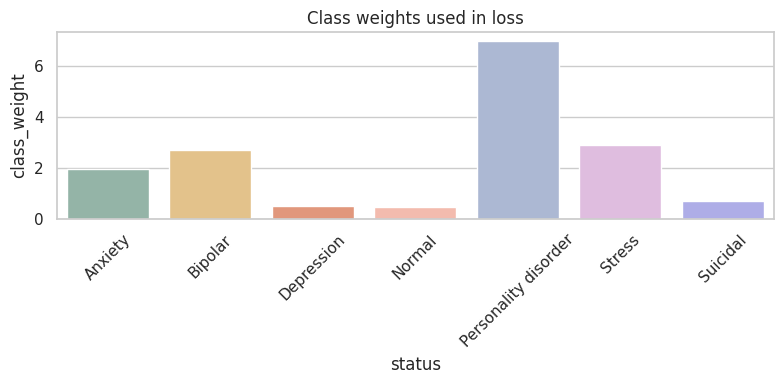

In [20]:
# SECTION 6 – Cell 4: visualise class weights with custom colours

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.barplot(
    data=weights_df,
    x="label",
    y="class_weight",
    order=LABEL_ORDER,
    palette=palette,
)
plt.title("Class weights used in loss")
plt.xlabel("status")
plt.ylabel("class_weight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
# SECTION 6 – Cell 5: loss function and optimizer

from torch.optim import AdamW
# Weighted CrossEntropyLoss with our computed class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

LR = 2e-5  # standard BERT fine-tuning lr
optimizer = AdamW(model.parameters(), lr=LR)

print("Loss function: CrossEntropyLoss with class weights")
print("Learning rate:", LR)

Loss function: CrossEntropyLoss with class weights
Learning rate: 2e-05


In [22]:
# SECTION 7 – Cell 2: train & evaluation helpers (with tqdm)

import torch
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    all_preds = []
    all_labels = []

    loop = tqdm(dataloader, desc="Training", leave=False)

    for batch in loop:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        loop.set_postfix({"batch_loss": loss.item()})

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, macro_f1


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0

    all_preds = []
    all_labels = []

    loop = tqdm(dataloader, desc="Validation", leave=False)

    for batch in loop:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss
        logits = outputs.logits

        total_loss += loss.item() * input_ids.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        loop.set_postfix({"batch_loss": loss.item()})

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, macro_f1


In [23]:
# SECTION 7 – Cell 3: training loop

import os

EPOCHS = 5 

train_losses = []
val_losses = []
val_accuracies = []
val_macro_f1s = []

best_val_f1 = -1.0
best_model_path = "models/mentalbert_best.pt"
os.makedirs("models", exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 30)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc, val_macro_f1 = evaluate(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_macro_f1s.append(val_macro_f1)

    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Train macro F1: {train_f1:.4f}")
    print(f"Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f} | Val   macro F1: {val_macro_f1:.4f}")

    # Save best model based on validation macro F1
    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        torch.save(model.state_dict(), best_model_path)
        print(f" New best model saved (val macro F1 = {best_val_f1:.4f})")

print("\nTraining finished.")
print(f"Best validation macro F1: {best_val_f1:.4f}")
print("Best model path:", best_model_path)


Epoch 1/5
------------------------------


Training:   0%|          | 0/2305 [00:00<?, ?it/s]

Validation:   0%|          | 0/494 [00:00<?, ?it/s]

Train loss: 0.5288 | Train acc: 0.7954 | Train macro F1: 0.7436
Val   loss: 0.4313 | Val   acc: 0.8233 | Val   macro F1: 0.7912
 New best model saved (val macro F1 = 0.7912)

Epoch 2/5
------------------------------


Training:   0%|          | 0/2305 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/494 [00:00<?, ?it/s]

Train loss: 0.1601 | Train acc: 0.9470 | Train macro F1: 0.9507
Val   loss: 0.7334 | Val   acc: 0.8349 | Val   macro F1: 0.8145
 New best model saved (val macro F1 = 0.8145)

Epoch 5/5
------------------------------


Training:   0%|          | 0/2305 [00:00<?, ?it/s]

Validation:   0%|          | 0/494 [00:00<?, ?it/s]

Train loss: 0.1114 | Train acc: 0.9669 | Train macro F1: 0.9687
Val   loss: 0.8569 | Val   acc: 0.8297 | Val   macro F1: 0.8090

Training finished.
Best validation macro F1: 0.8145
Best model path: models/mentalbert_best.pt


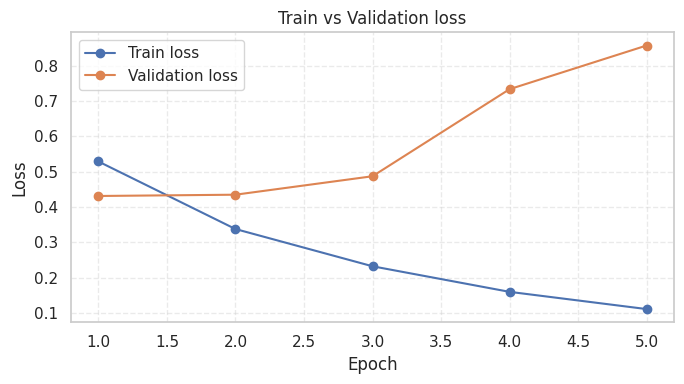

In [24]:
# SECTION 7 – Cell 4: plot train vs validation loss

import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, train_losses, marker="o", label="Train loss")
plt.plot(epochs_range, val_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

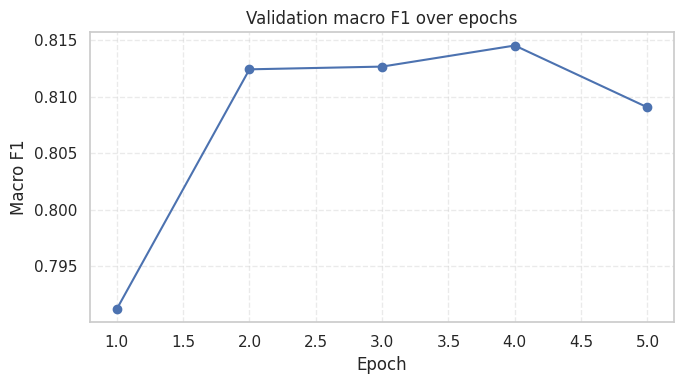

In [25]:
# SECTION 7 – Cell 5: plot validation macro F1 per epoch

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, val_macro_f1s, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation macro F1 over epochs")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()